In [56]:
include("MiniCollectiveSpins.jl")
using PyPlot
using Statistics
using JLD2
using ProgressBars

### Define the system

In [57]:
# Parameters
N = 10
r = 100
Sat = [0:5:60;]
n0 = 1e3#1279

# Quantization axis along z
e = [0, 0, 1.]

# Constants
λ = 421e-9
γ = 32.7e6 # In Hz

# Rabi frequency
Ω_RO = γ.*sqrt.(Sat/2)

# Normalisation
Ω_RO /= γ


@load "op_list/op_list_$N.jdl2" op_list;

# Plots of the time evolution

0.0%┣                                               ┫ 0/13 [00:00<00:00, -0s/it]
7.7%┣███▎                                       ┫ 1/13 [00:02<Inf:Inf, InfGs/it]
15.4%┣███████                                       ┫ 2/13 [00:18<03:21, 18s/it]
23.1%┣██████████▋                                   ┫ 3/13 [00:22<01:50, 11s/it]
30.8%┣██████████████▌                                ┫ 4/13 [00:25<01:16, 8s/it]
38.5%┣██████████████████                             ┫ 5/13 [00:28<00:56, 7s/it]
46.2%┣█████████████████████▊                         ┫ 6/13 [00:31<00:44, 6s/it]
53.8%┣█████████████████████████▎                     ┫ 7/13 [00:39<00:39, 7s/it]
61.5%┣█████████████████████████████                  ┫ 8/13 [00:51<00:36, 7s/it]
69.2%┣████████████████████████████████▌              ┫ 9/13 [00:58<00:29, 7s/it]
76.9%┣███████████████████████████████████▍          ┫ 10/13 [01:01<00:20, 7s/it]
84.6%┣███████████████████████████████████████       ┫ 11/13 [01:10<00:14, 7s/it]
92.3%┣██████████████████████

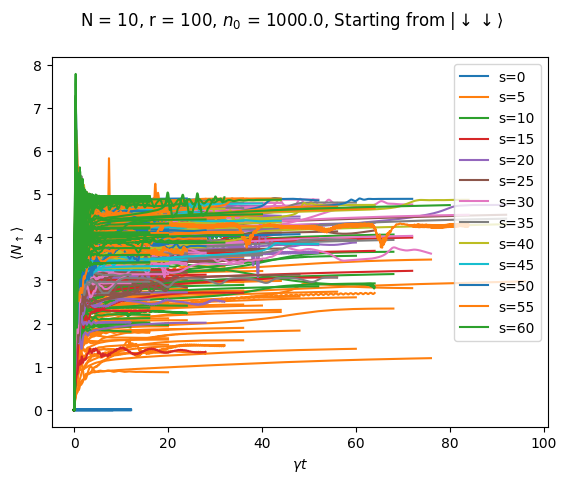

<sys>:0: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


In [58]:
close("all")
fig, ax = subplots() 

list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, s) in ProgressBar(enumerate(Sat))
    line = []
    @load "solutions/sol_N_$(N)_r_$(r)_sat_$(s)_n0_$n0.jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t)
        if j ∉ nbr_error
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="s=$(s)")
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  N_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

0.0%┣                                               ┫ 0/13 [00:00<00:00, -0s/it]
15.4%┣███████▎                                       ┫ 2/13 [00:00<00:02, 7it/s]
23.1%┣██████████▉                                    ┫ 3/13 [00:00<00:01, 8it/s]
30.8%┣██████████████▏                               ┫ 4/13 [00:00<00:01, 10it/s]
38.5%┣█████████████████▊                            ┫ 5/13 [00:00<00:01, 10it/s]
46.2%┣█████████████████████▎                        ┫ 6/13 [00:00<00:01, 10it/s]
53.8%┣████████████████████████▊                     ┫ 7/13 [00:01<00:01, 10it/s]
69.2%┣███████████████████████████████▉              ┫ 9/13 [00:01<00:00, 12it/s]
76.9%┣██████████████████████████████████▋          ┫ 10/13 [00:01<00:00, 12it/s]
92.3%┣█████████████████████████████████████████▌   ┫ 12/13 [00:01<00:00, 13it/s]
100.0%┣████████████████████████████████████████████┫ 13/13 [00:01<00:00, 13it/s]
100.0%┣████████████████████████████████████████████┫ 13/13 [00:01<00:00, 13it/s]


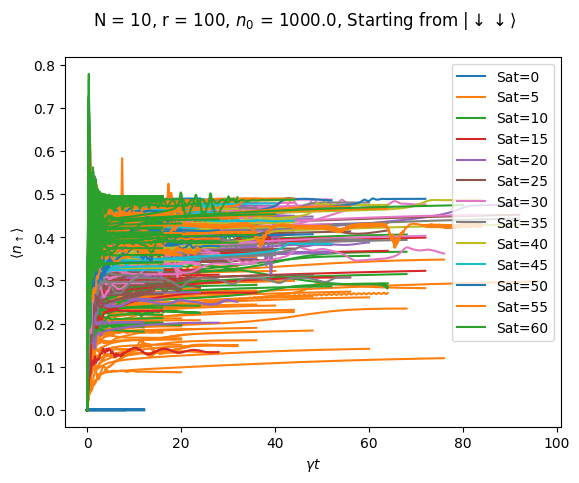

In [59]:
close("all")
fig, ax = subplots()

for (i, s) in ProgressBar(enumerate(Sat))
    line = []
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, label="Sat=$(s)")
            else
                ax.plot(list_t_N[i][j], popup_t_N[i][j] / N, color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Mean of the SS

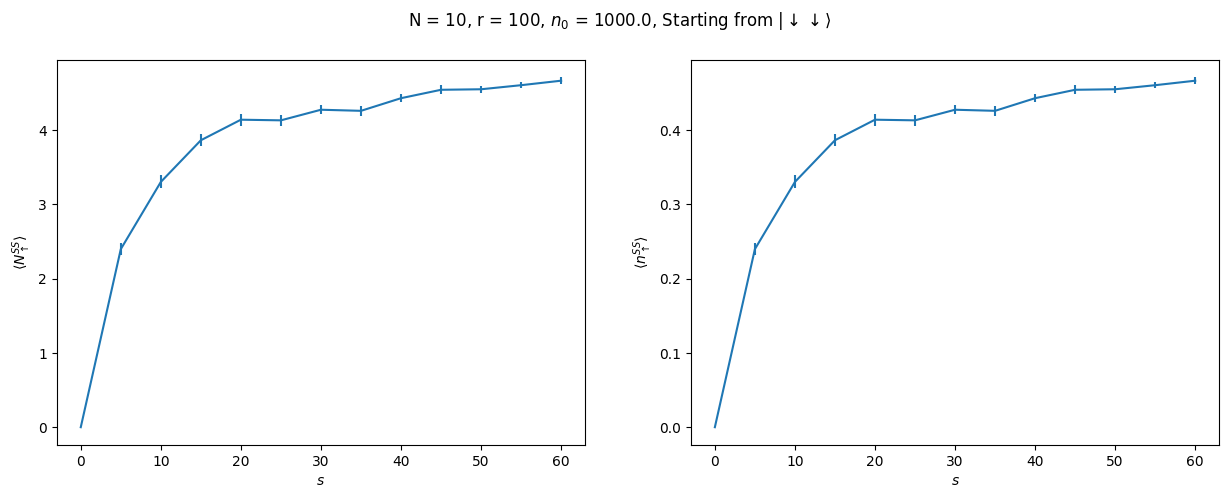

In [60]:
# For Sat = 0, only throws errors as density to close from 0 --> remove the errors 
if 0 ∈ Sat
    idx = findall(Sat .== 0)[1]
    for i in 1:length(nbr_error_t_N[idx])
        if maximum(abs.(popup_t_N[idx][nbr_error_t_N[idx][i]])) < 10
            nbr_error_t_N[idx][i] = 0 # Physical solution
        end
    end
end

mean_SS = mean.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j ∉ nbr_error_t_N[i]] for i = 1:length(popup_t_N)])
std_SS = std.([[popup_t_N[i][j][end] for j = 1:length(popup_t_N[i]) if j∉nbr_error_t_N[i]] for i = 1:length(popup_t_N)])

fig, axes = subplots(1, 2, figsize = (15, 5))
axes[1].errorbar(Sat, mean_SS, yerr=std_SS ./ sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(Sat)]))
axes[1].set_xlabel(L"s")
axes[1].set_ylabel(L"$\langle  N_{\uparrow}^{SS} \rangle $")

axes[2].errorbar(Sat, mean_SS./N, yerr=std_SS ./ (N .* sqrt.([length(popup_t_N[i])-length(nbr_error_t_N[i]) for i = 1:length(Sat)])))
axes[2].set_xlabel(L"s")
axes[2].set_ylabel(L"$\langle  n_{\uparrow}^{SS} \rangle $")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $")

pygui(false); gcf();
# pygui(true); show()

# Evolution of $\braket{\sigma^+}$ and $\braket{\sigma^-}$

In [61]:
I_laser = []
I_laser_SS = []

for (i, s) in ProgressBar(enumerate(Sat))
    Il, Il_SS = [], []
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                σp_t = [sum(sol_t_N[i][j][t][N+1:2*N]) for t =1:length(list_t_N[i][j])]
                push!(Il, Ω_RO[i]*real.(σp_t))
                push!(Il_SS, Il[end][end])
            else # Only the SS was saved
                σp_SS = sum(sol_t_N[i][j][N+1:2*N])
                push!(Il_SS, Ω_RO[i]*real(σp_SS))
            end
        else
            push!(Il, [])
            push!(Il_SS, [])
        end
    end
    push!(I_laser, Il)
    push!(I_laser_SS, Il_SS)
end     

0.0%┣                                               ┫ 0/13 [00:00<00:00, -0s/it]
7.7%┣███▎                                       ┫ 1/13 [00:01<Inf:Inf, InfGs/it]
15.4%┣███████▎                                       ┫ 2/13 [00:06<01:07, 6s/it]
23.1%┣██████████▉                                    ┫ 3/13 [00:12<01:02, 6s/it]
30.8%┣██████████████▌                                ┫ 4/13 [00:19<00:56, 6s/it]
38.5%┣██████████████████                             ┫ 5/13 [00:21<00:43, 5s/it]
46.2%┣█████████████████████▊                         ┫ 6/13 [00:26<00:37, 5s/it]
53.8%┣█████████████████████████▎                     ┫ 7/13 [00:55<00:55, 9s/it]
61.5%┣████████████████████████████▎                 ┫ 8/13 [01:14<00:53, 11s/it]
69.2%┣███████████████████████████████▉              ┫ 9/13 [01:25<00:42, 11s/it]
76.9%┣██████████████████████████████████▋          ┫ 10/13 [01:31<00:30, 10s/it]
84.6%┣██████████████████████████████████████       ┫ 11/13 [01:39<00:20, 10s/it]
92.3%┣██████████████████████

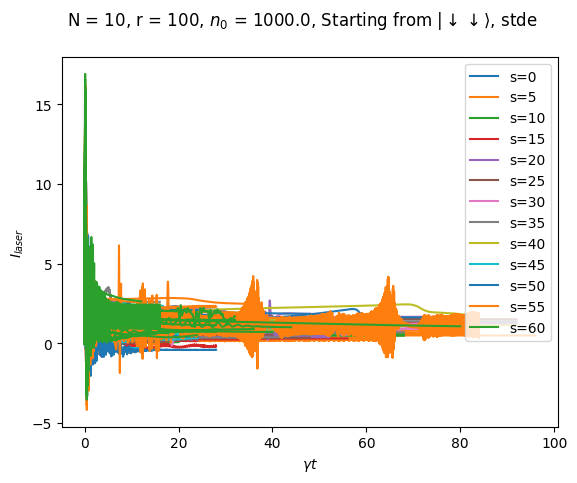

false

In [62]:
if length(sol_t_N[end][1][end]) > 1
    close("all")
    fig = subplots()

    for i in 1:length(Sat)
        line = []
        for j in 1:r
            if j ∉ nbr_error_t_N[i]
                if line == []
                    line, = plot(list_t_N[i][j], I_laser[i][j], label="s=$(Sat[i])")
                else
                    plot(list_t_N[i][j], I_laser[i][j], color=line.get_color())
                end
            end
        end
    end

    xlabel(L"$\gamma t$")
    ylabel(L"$I_{laser}$")

    suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
    legend()

    # pygui(true); show()
    pygui(false);
end

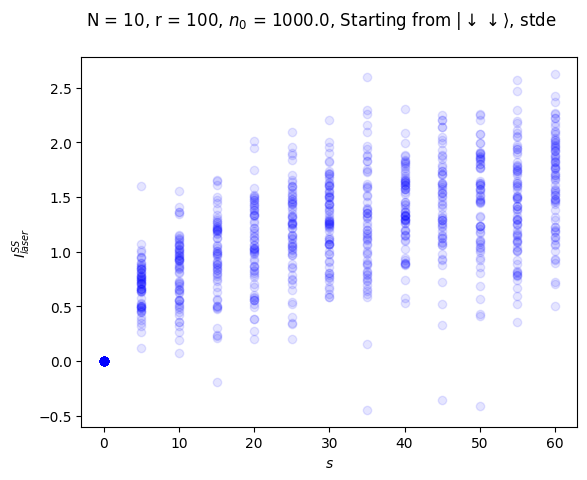

In [63]:
close("all")
fig = subplots()

# errorbar(Sat, [mean([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="SE from SR SS")

for i in 1:length(Sat)
    line = []
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], I_laser_SS[i][j], color="b", alpha=0.1)
        end
    end
end

xlabel(L"$s$")
ylabel(L"$I_{laser}^{SS}$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")

# pygui(true); show()
pygui(false);

# Compute $\gamma_{SE}$ from the SR SS

In [64]:
I_SE_SR_SS = zeros(ComplexF64, (length(Sat), r))

for (i, s) in enumerate(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                I_SE_SR_SS[i, j] += Γ_CS[a, a]*sol_SS[a]
            end
            I_SE_SR_SS[i, j] /= N
        end
    end
end
I_SE_SR_SS = real.(I_SE_SR_SS);

# Compute $\gamma_{SR}$ from the SR SS

In [65]:
I_SR_SR_SS = zeros(ComplexF64, (length(Sat), r))

for (i, s) in enumerate(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            @load "r0/r0_N_$(N)_n0_$(n0)_r_$j.jdl2" r0 L
            system = SpinCollection(r0, e, gammas=1.)
            Γ_CS = GammaMatrix(system)
            
            if length(sol_t_N[i][j][end]) > 1 # If the full solution yas saved
                sol_SS = sol_t_N[i][j][end]
            else
                sol_SS = sol_t_N[i][j] # Only the SS was saved
            end

            for a = 1:N
                for b = 1:N
                    if b > a # Correlated decay
                        corr = [21*10^(floor(Int, log10(a))+1)+a, 12*10^(floor(Int, log10(b))+1)+b]
                        # corr = [22*10^(floor(Int, log10(a))+1)+a, 22*10^(floor(Int, log10(b))+1)+b]
                        try
                            I_SR_SR_SS[i, j] += 2*Γ_CS[a, b]*sol_SS[findall(x->x==corr || x==reverse(corr), op_list)[1]]
                        catch
                            println("Error @ $N, r=$j, a=$a, b=$b, corr=$corr")
                        end
                    end
                end
            end
            I_SR_SR_SS[i, j] /= N
        end
    end
end
I_SR_SR_SS = real.(I_SR_SR_SS);

In [66]:
Itot = I_SE_SR_SS .+ I_SR_SR_SS;

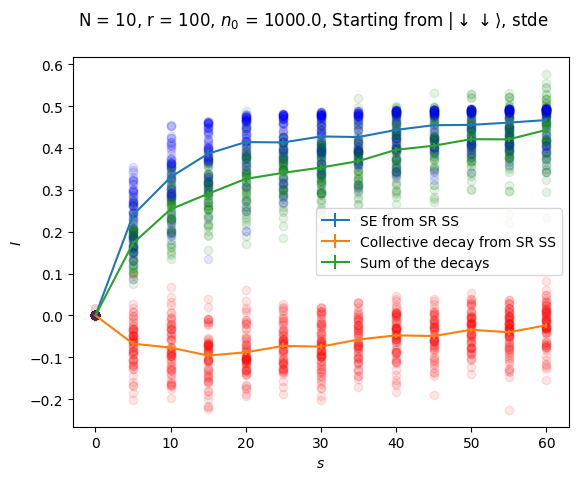

In [67]:
close("all")
fig = subplots()

errorbar(Sat, [mean([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="SE from SR SS")
errorbar(Sat, [mean([I_SR_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([I_SR_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Collective decay from SR SS")
errorbar(Sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Sum of the decays")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], Itot[i, j], alpha=0.1, color="green")
            scatter(Sat[i], I_SE_SR_SS[i, j], alpha=0.1, color="b")
            scatter(Sat[i], I_SR_SR_SS[i, j], alpha=0.1, color="r")
        end
    end
end

xlabel(L"s")
ylabel(L"$I$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

# Convert to photon/$m^2$

In [68]:
Itot *= γ
I_SE_SR_SS *= γ
I_SR_SR_SS *= γ

@load "r0/r0_N_$(N)_n0_$(n0)_r_1.jdl2" r0 L
Itot /= 6*(L*λ)^2
I_SE_SR_SS /= 6*(L*λ)^2
I_SR_SR_SS /= 6*(L*λ)^2;

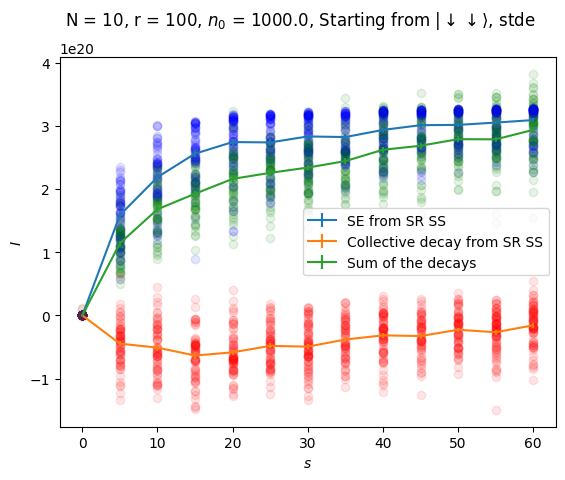

In [69]:
close("all")
fig = subplots()

errorbar(Sat, [mean([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([I_SE_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="SE from SR SS")
errorbar(Sat, [mean([I_SR_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([I_SR_SR_SS[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Collective decay from SR SS")
errorbar(Sat, [mean([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]]) for i in 1:length(Sat)], yerr=[std([Itot[i, j] for j in 1:r if j ∉ nbr_error_t_N[i]])/sqrt(r-length(nbr_error_t_N[i])) for i in 1:length(Sat)], label="Sum of the decays")

for i in 1:length(Sat)
    for j in 1:r
        if j ∉ nbr_error_t_N[i]
            scatter(Sat[i], Itot[i, j], alpha=0.1, color="green")
            scatter(Sat[i], I_SE_SR_SS[i, j], alpha=0.1, color="b")
            scatter(Sat[i], I_SR_SR_SS[i, j], alpha=0.1, color="r")
        end
    end
end

xlabel(L"s")
ylabel(L"$I$")

suptitle("N = $N, r = $r, "*L"$n_0$"*" = $n0, Starting from "*L"$|\downarrow \downarrow \rangle $, stde")
legend()

# pygui(true); show()
pygui(false);

In [70]:
if !isdir("Itot")
    mkdir("Itot")
end
@save "Itot/Itot_N_$(N)_r_$(r)_Sat_$(Sat)_n0_$(n0)_decay_rate_up_down.jdl2" Sat Itot I_SE_SR_SS I_SR_SR_SS nbr_error_t_N